# DC only operation optimization

This notebook is used to prototype the operation optimization of the DC only 
cooling system. It should aim at finding the optimal operation of the DC, that is,
providing the required cooling power at the lowest possible cost (electricity consumption).

minimize: $J\:[u.m.] = J_{e}\:[kW_e] \cdot C_{e}\:[u.m./kWh_e] \cdot T_s\:[h]$ 

where:
- $J$: total cost of operation (u.m.)
- $J_{e}$: electricity consumption (kW_e)
- $T_s$: sample time (h)

Inputs:
- $T_{amb}$: Ambient temperature (°C)
- $C_{e}$: Electricity cost (u.m./kWh_e)
- $T_{v,ref}$: Desired load vapor temperature (°C)
- $\dot{m}_{v}$: Load vapor mass flow rate (kg/s) 

Decision variables:
- $w_{dc}$: DC fan feed frequency (%)
- $q_{c}$: Cooling water recirculation flow rate (m³/h)

Constraints:
- |$T_{v,ref} - T_v$|$\lt 0.5$
- $w_{dc} \in [\underline{w}_{dc}, \overline{w}_{dc}]$ (%)
- $q_{c} \in [\underline{q}_{c}, \overline{q}_{c}]$ (m³/h)


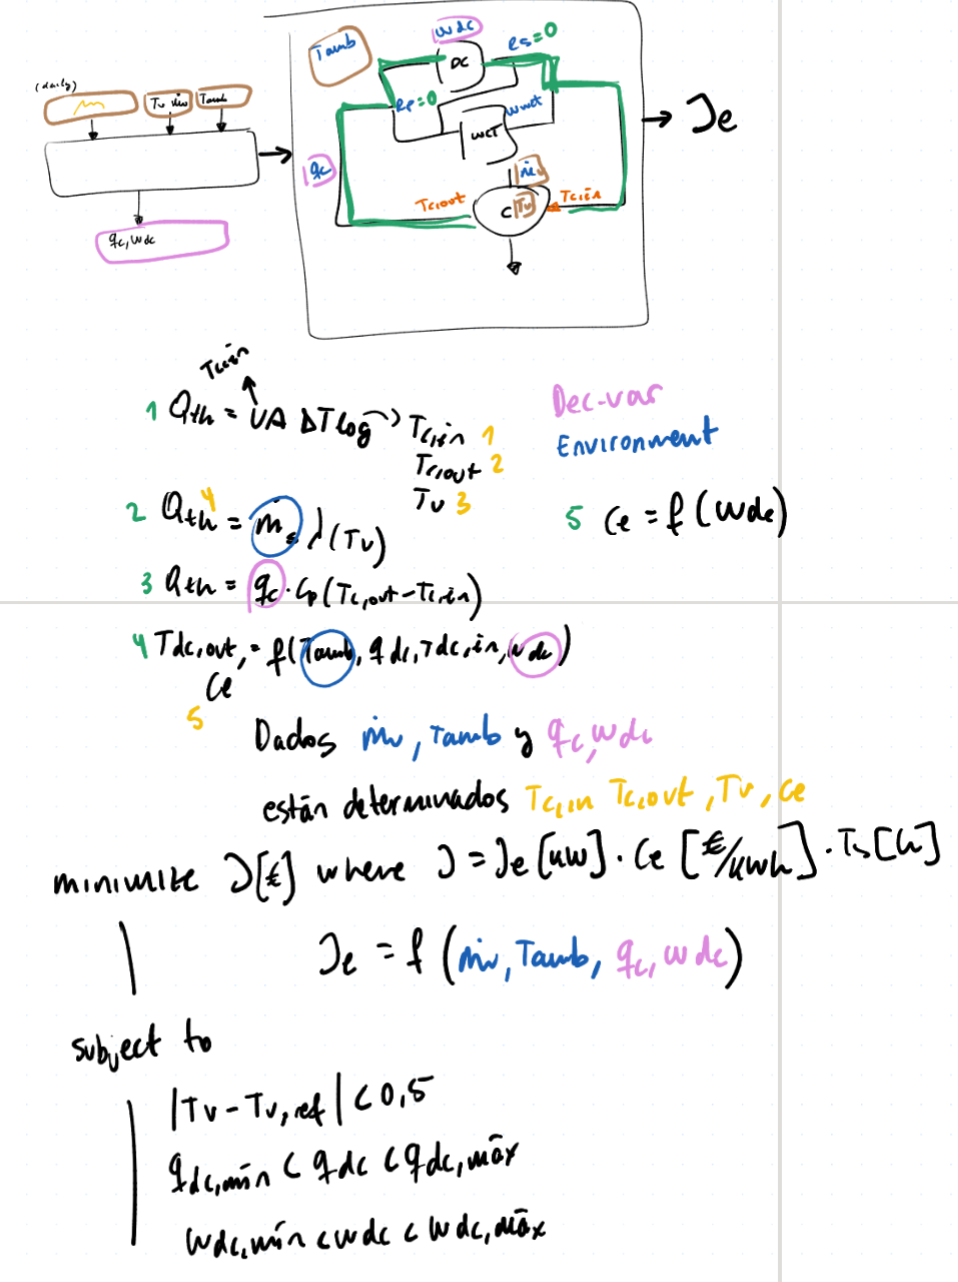


In [2]:
# TODO: Switch using uv python environment to conda in order to use pygmo
# Requirements:
# - [ ] Electricy price timeseries data for a full year (Ce, units?)
# - [ ] Ambient temperature for timeseries for a full year (Tamb, ºC)
# - [ ] Load conditions (mass flow rate and temperature) for a full year (mv and Tv, kg/s and ºC)

# Implementation steps:
# - [ ] Build load conditions profile
# - [ ] If not available, make up some data for electricity price
# - [ ] Define a pygmo problem interface for the DC problem (real-time optimization at each step using some local solver)
# - [ ] Evaluate for a full day


In [3]:
from pathlib import Path
import pandas as pd

data_path: Path = Path("../../data")
env_path: Path = data_path / "datasets/environment_data_20220101_20241231.h5"


In [4]:
# Load environment into EnvironmentVariables for the episode
df_env = pd.read_hdf(env_path)
df_env


,G_Gh,G_Dh,G_Gk,G_Bn,Tamb_C,HR_pct,hs,Az,precip_mm,Td,Ce_pvpc_eur_MWh,Ce_spot_market_price_eur_MWh,Pth_kW,Tv_C
2022-01-01 00:00:00+00:00,0.0,0.0,0.0,0.0,10.7,90.0,0.0,-144.0,6.7,9.1,171.35,114.90,200.0,35.0
2022-01-01 01:00:00+00:00,0.0,0.0,0.0,0.0,11.6,82.0,0.0,-163.4,0.5,8.7,172.70,113.87,200.0,35.0
2022-01-01 02:00:00+00:00,0.0,0.0,0.0,0.0,11.3,82.0,0.0,-124.4,0.5,8.4,156.07,97.80,200.0,35.0
2022-01-01 03:00:00+00:00,0.0,0.0,0.0,0.0,11.2,82.0,0.0,-105.4,0.3,8.3,159.08,97.80,200.0,35.0
2022-01-01 04:00:00+00:00,0.0,0.0,0.0,0.0,11.0,82.0,0.0,-93.6,0.2,8.1,157.28,95.74,200.0,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 18:00:00+00:00,0.0,0.0,0.0,0.0,6.0,98.0,0.0,115.2,1.6,5.7,274.90,159.44,200.0,35.0
2024-12-31 19:00:00+00:00,0.0,0.0,0.0,0.0,6.0,98.0,0.0,115.2,1.6,5.7,271.27,156.10,200.0,35.0
2024-12-31 20:00:00+00:00,0.0,0.0,0.0,0.0,6.0,98.0,0.0,115.2,1.6,5.7,268.41,150.85,200.0,35.0
2024-12-31 21:00:00+00:00,0.0,0.0,0.0,0.0,6.0,98.0,0.0,115.2,1.6,5.7,212.84,144.40,200.0,35.0


In [22]:
from dataclasses import dataclass, asdict
import numpy as np
from datetime import datetime
from typing import Literal
from collections.abc import Iterable
import pygmo as pg
from iapws import IAPWS97 as w_props

import combined_cooler_model
import matlab

from solhycool_optimization.utils import dump_in_span

# Box bounds can include all decision variables, not just the DC ones
@dataclass
class RealDecVarsBoxBounds:
    """ Real decision variables box bounds, as in: (lower bound, upper bound)"""
    qc: tuple[float, float] = (5.2211, 24.1543)
    Rp: tuple[float, float] = (0., 1.)
    Rs: tuple[float, float] = (0., 1.)
    wdc: tuple[float, float] = (11.0, 99.1800)
    wwct: tuple[float, float] = (0., 93.4161)
    
@dataclass
class EnvironmentVariables:
    """
    Simple class to make sure that the required environment variables are passed
    
    All the variables should be 1D arrays with as many elements as the horizon of the optimization problem
    """
    # Weather
    HR: float | np.ndarray[float] | pd.Series  # Relative humidity, %
    Tamb: float | np.ndarray[float] | pd.Series # Ambient temperature, ºC
    
    # Thermal load
    Tv: float | np.ndarray[float] | pd.Series # Vapor temperature, ºC
    Pth: float | np.ndarray[float] | pd.Series # Thermal power, kW
    
    # Costs
    cost_e: float | np.ndarray[float] | pd.Series # Cost of electricity, €/kWhe
    cost_w: float | np.ndarray[float] | pd.Series = None # Cost of water, €/m³ 

    # Thermal load (optional)
    mv: float | np.ndarray[float] | pd.Series = None # Vapor mass flow rate, kg/s
    
    def __post_init__(self) -> None:
        if isinstance(self.Tv, matlab.double):
            Tv = np.asarray(self.Tv).flatten()[0]
            Pth = np.asarray(self.Pth).flatten()[0]
        else:
            Tv = self.Tv
            Pth = self.Pth
            
        # Calculate mv
        mv = Pth / (w_props(T=Tv+273.15, x=1).h - w_props(T=Tv+273.15, x=0).h) * 3600
        
        if isinstance(self.Tv, matlab.double):
            self.mv = matlab.double([mv])
        else:
            self.mv = mv
    
    def dump_at_index(self, idx: int, return_dict: bool = False, return_format: Literal["float", "matlab"] = "float") -> "EnvironmentVariables":
        """
        Dump instance at a given index.

        Parameters:
        - idx: Integer index to extract.

        Returns:
        - A dictionary.
        """
        dump =  {name: np.asarray(value)[idx] for name, value in asdict(self).items() if value is not None}
        if return_format == "matlab":
            dump = {k: matlab.double([v]) for k, v in dump.items()}        
        
        return dump if return_dict else EnvironmentVariables(**dump)
    
    def dump_in_span(self, span: tuple[int, int] | tuple[datetime, datetime], return_format: Literal["values", "series"] = "values") -> 'EnvironmentVariables':
        """ Dump environment variables within a given span """
        
        vars_dict = dump_in_span(vars_dict=asdict(self), span=span, return_format=return_format)
        return EnvironmentVariables(**vars_dict)
    
    def resample(self, *args, **kwargs) -> "EnvironmentVariables":
        """ Return a new resampled environment variables instance """
        
        output = {}
        for name, value in asdict(self).items():
            if value is None:
                continue
            elif not isinstance(value, pd.Series):
                raise TypeError(f"All attributes must be pd.Series for datetime indexing. Got {type(value)} instead.")
            
            target_freq = int(float(args[0][:-1]))
            current_freq = value.index.freq.n
            
            value = value.resample(*args, **kwargs)
            if  target_freq > current_freq: # Downsample
                value = value.mean()
            else: # Upsample
                value = value.interpolate()
            output[name] = value
            
        return EnvironmentVariables(**output)
    
    def to_matlab(self) -> "EnvironmentVariables":
        """ Convert all attributes to matlab.double """
        
        return EnvironmentVariables(**{k: matlab.double(v) for k, v in asdict(self).items() if v is not None})
    
@dataclass
class DecisionVariables:
    qc: float
    Rp: float
    Rs: float
    wdc: float
    wwct: float
        
class Problem:
    env_vars: EnvironmentVariables # Environment variables
    store_x: bool # Store decision variables
    store_fitness: bool # Store fitness values
    real_dec_vars_box_bounds: RealDecVarsBoxBounds
    x_evaluated: list[list[float]] # Decision variables vector evaluated (i.e. sent to the fitness function)
    fitness_history: list[float] # Fitness record of decision variables sent to the fitness function
    dec_var_ids: list[str] = ["qc", "wdc"] # Decision variables ids
    size_dec_vector: int = 2 # Size of the decision vector
    cc_model: combined_cooler_model # Combined cooler model
    c_tol: float = 0.5 # Constraint tolerance
    
    def __init__(self, 
                 env_vars: EnvironmentVariables, 
                 store_x: bool = False,
                 store_fitness: bool = False,
                 real_dec_vars_box_bounds: RealDecVarsBoxBounds = RealDecVarsBoxBounds(),
                ) -> None:
        
        self.real_dec_vars_box_bounds = real_dec_vars_box_bounds
        self.env_vars = env_vars
        self.store_x = store_x
        self.store_fitness = store_fitness
        
        self.cc_model = combined_cooler_model.initialize() # Could we get away initiating this only once at the beginning?
        # self.cc_model.warning('off', 'all', nargout=0)  # Turns off all warnings
    
    def get_nic(self) -> int:
        return 1
    
    def gradient(self, x):
        return pg.estimate_gradient(lambda x: self.fitness(x), x) # we here use the low precision gradient
    
    def decision_vector_to_decision_variables(self, x: np.ndarray[float]) -> DecisionVariables:
        
        return DecisionVariables(
            qc=matlab.double([x[0]]),
            Rp=matlab.double([0.0]),
            Rs=matlab.double([0.0]),
            wdc=matlab.double([x[1]]),
            wwct=matlab.double([0])
        )
    
    def get_bounds(self, ) -> tuple[Iterable, Iterable]:
        
        lb = [self.real_dec_vars_box_bounds.qc[0], self.real_dec_vars_box_bounds.wdc[0]]
        ub = [self.real_dec_vars_box_bounds.qc[0], self.real_dec_vars_box_bounds.wdc[1]]
        
        return lb, ub
    
    def fitness(self, x: np.ndarray[float], debug_mode: bool = False) -> list[float]:
        
        dv = self.decision_vector_to_decision_variables(x)
        ev = self.env_vars.to_matlab()

        Ce_kWe, _, detailed = self.cc_model.combined_cooler_model(ev.Tamb, ev.HR, ev.mv, dv.qc, dv.Rp, dv.Rs, dv.wdc, dv.wwct, matlab.double([ev.Tv]), nargout=3)
        
        # Calculate thermal power using Tc_in and Tc_out, and return difference with the setpoint
        Pth = 4.186 * detailed["qc"][0][0]/3600 * (detailed["Tc_in"][0][0] - detailed["Tc_out"][0][0])
        
        # Store decision vector and fitness value
        if self.store_x:
            self.x_evaluated.append(x.tolist())
        if self.store_fitness:
            self.fitness_history.append(Ce_kWe)
   
        return [Ce_kWe, abs(detailed["Pth"] - Pth)]
        # return [Ce_kWe, abs(detailed["Tv"] - ev.Tv[0][0])]
    
    def terminate(self) -> None:
        self.cc_model.terminate()


In [6]:
df_env.columns


Index(['G_Gh', 'G_Dh', 'G_Gk', 'G_Bn', 'Tamb_C', 'HR_pct', ' hs', ' Az',
       'precip_mm', ' Td', 'Ce_pvpc_eur_MWh', 'Ce_spot_market_price_eur_MWh',
       'Pth_kW', 'Tv_C'],
      dtype='object')

In [7]:
from iapws import IAPWS97 as w_props

Tv = df_env.iloc[0]["Tv_C"]
Pth = df_env.iloc[0]["Pth_kW"]
lambda_ = w_props(T=Tv+273.15, x=1).h - w_props(T=Tv+273.15, x=0).h # [kJ/kg]
mv = Pth / lambda_ # [kg/s]

print(f"{Tv=} [ºC], {Pth=} [kWth], {lambda_=} [kJ/kg], {mv=:.2f} [kg/s] -> {mv*3600=:.2f} [kg/h]")


Tv=35.0 [ºC], Pth=200.0 [kWth], lambda_=2417.939780353978 [kJ/kg], mv=0.08 [kg/s] -> mv*3600=297.77 [kg/h]


In [23]:
# Test the problem for one step
import pygmo as pg
from iapws import IAPWS97 as w_props

ds = df_env.iloc[0]
env_vars = EnvironmentVariables(
    HR=ds["HR_pct"],
    Tamb=ds["Tamb_C"],
    Pth=ds["Pth_kW"],
    # mv=ds["Pth_kW"] / (w_props(T=ds["Tv_C"]+273.15, x=1).h - w_props(T=ds["Tv_C"]+273.15, x=0).h) * 3600,
    Tv=ds["Tv_C"],
    cost_w=None,
    cost_e=ds["Ce_spot_market_price_eur_MWh"]*1e-3
)

# HR: float | np.ndarray[float] | pd.Series  # Relative humidity, %
# Tamb: float | np.ndarray[float] | pd.Series # Ambient temperature, ºC

# # Thermal load
# mv: float | np.ndarray[float] | pd.Series # Vapor mass flow rate, kg/s
# Tv: float | np.ndarray[float] | pd.Series # Vapor temperature, ºC

# # Costs
# cost_w: float | np.ndarray[float] | pd.Series # Cost of water, €/m³ 
# cost_e:
        
problem = Problem(env_vars=env_vars)

display(problem.get_bounds())
display(problem.fitness(x=np.array([8., 50.])))


([5.2211, 11.0], [5.2211, 99.18])

> In wct_model (line 52)
In combined_cooler_model (line 112)
> In wct_model (line 52)
In combined_cooler_model (line 112)
> In combined_cooler_model (line 119)


TypeError: 'float' object is not subscriptable

In [1]:
prob = pg.problem(problem)
prob.c_tol = problem.c_tol
ip = pg.ipopt()
ip.set_numeric_option("tol",1E-1) # Change the relative convergence tolerance

algo = pg.algorithm(ip)
algo.set_verbosity(1)

pop = pg.population(prob, 1)
pop = algo.evolve(pop)

pop.champion_x, pop.champion_f


NameError: name 'pg' is not defined

In [ ]:
# Build a simulation for an episode (full day)
